# Rateio de Custos da Divisao APOIO - por Plano de Contas

Este notebook le os lancamentos do CSV mensal (`APOIO_{Mes}.csv`), soma o **`valor_centro`** e quebra o total **por plano de contas** (`descdc`) — cada plano de contas vira uma fatia da pizza.

## Uso mensal

1. Exporte/coloque o arquivo em `02-Referencias/Meus_Dados/` com nome no padrao `APOIO_Marco.csv`, `APOIO_Abril.csv`, etc.
2. Na celula **Configuracao mensal**, altere apenas `NOME_MES`.
3. Execute todas as celulas (**Run All**).

## Logica aplicada
- `valor_total = soma(valor_centro)` em todas as linhas do APOIO no mes
- Para cada plano de contas (`descdc`):
  - `valor_pc = soma(valor_centro)` daquele plano
  - `participacao = valor_pc / valor_total`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

plt.style.use('default')


## Configuracao mensal

### Padrao do arquivo de lancamentos

| Arquivo na pasta `Meus_Dados` | Valor de `NOME_MES` |
| --- | --- |
| `APOIO_Marco.csv` | `"Marco"` |
| `APOIO_Abril.csv` | `"Abril"` |

Nome gerado pelo notebook: `APOIO_{NOME_MES}.csv`


In [2]:
# ========= CONFIGURACAO MENSAL (editar todo mes) =========
NOME_MES = "Março"

# Pasta dentro de 02-Referencias/
PASTA_MEUS_DADOS = "Meus_Dados"

# Padrao do nome do arquivo: use {mes} como placeholder
PADRAO_NOME_ARQUIVO = "APOIO_{mes}.csv"
# ========================================================


## 2) Entrada de dados

- **Lancamentos:** o caminho vem da config acima: `02-Referencias/Meus_Dados/` + `APOIO_{NOME_MES}.csv` (sep `;`).
- **Coluna do valor:** `valor_centro` (mesma da tabela dinamica do `Rateio_APOIO_{Mes}.xlsx`).
- **Coluna do agrupamento:** `descdc` (descricao do plano de contas).


## Diagnóstico: por que o total do notebook difere da tabela dinâmica?

Esta célula lê o xlsx (`Rateio_APOIO_{NOME_MES}.xlsx`), compara com o CSV e mostra as linhas que estão **faltando no CSV**.

In [ ]:
def _ler_xlsx_apoio(root: Path, nome_mes: str) -> pd.DataFrame | None:
    """Tenta ler a aba de dados do Rateio_APOIO_{mes}.xlsx se ele existir."""
    padrao = f"Rateio_APOIO_{nome_mes}.xlsx"
    caminho = root / "02-Referencias" / padrao
    if not caminho.is_file():
        print(f"[diagnóstico] Arquivo xlsx não encontrado: {caminho}")
        return None
    try:
        xl = pd.ExcelFile(caminho, engine="openpyxl")
        abas_dados = [a for a in xl.sheet_names if "APOIO" in a.upper() and "TD" not in a.upper()]
        if not abas_dados:
            print(f"[diagnóstico] Nenhuma aba de dados encontrada. Abas: {xl.sheet_names}")
            return None
        aba = abas_dados[0]
        df = xl.parse(aba, dtype=str)
        df.columns = df.columns.str.strip()
        print(f"[diagnóstico] Aba lida: '{aba}' | Linhas no xlsx: {len(df)}")
        return df
    except Exception as e:
        print(f"[diagnóstico] Erro ao ler xlsx: {e}")
        return None


df_xlsx = _ler_xlsx_apoio(ROOT, NOME_MES)

if df_xlsx is not None:
    # Normaliza valor_centro em ambos os DataFrames para comparação numérica
    df_xlsx["_vc_num"] = df_xlsx["valor_centro"].map(parse_monetario)
    total_xlsx = df_xlsx["_vc_num"].sum()

    print(f"\n{'='*55}")
    print(f"  Total valor_centro no xlsx  : R$ {total_xlsx:>12,.2f}")
    print(f"  Total valor_centro no CSV   : R$ {valor_total:>12,.2f}")
    print(f"  Diferença                   : R$ {(total_xlsx - valor_total):>12,.2f}")
    print(f"{'='*55}")

    # Identifica linhas presentes no xlsx mas ausentes no CSV
    # Chave de comparação: cab_pagrec_id + codcdc (identifica cada lançamento único)
    def _chave(df):
        return df["cab_pagrec_id"].astype(str).str.strip() + "|" + df["codcdc"].astype(str).str.strip()

    chaves_csv  = set(_chave(lancamentos))
    chaves_xlsx = set(_chave(df_xlsx))
    faltando_no_csv = chaves_xlsx - chaves_csv

    if faltando_no_csv:
        mask = _chave(df_xlsx).isin(faltando_no_csv)
        ausentes = df_xlsx[mask][["codcen", "descdc", "nome", "valor_centro", "_vc_num"]].copy()
        ausentes = ausentes.sort_values("_vc_num")
        total_ausente = ausentes["_vc_num"].sum()

        print(f"\n⚠️  Linhas presentes no xlsx mas AUSENTES no CSV ({len(ausentes)} linhas):")
        display(ausentes.drop(columns="_vc_num").reset_index(drop=True))
        print(f"\n  Soma das linhas ausentes: R$ {total_ausente:,.2f}")
        print(f"  Isso explica a diferença? {'✅ SIM' if abs((total_xlsx - valor_total) - total_ausente) < 0.02 else '❌ Diferença residual de R$ ' + f'{(total_xlsx - valor_total) - total_ausente:,.2f}'}")
    else:
        print("\n✅ Nenhuma linha ausente detectada pela chave cab_pagrec_id+codcdc.")
        print("   A diferença pode ser por valores diferentes nas mesmas chaves — verifique manualmente.")


In [3]:
def _resolver_raiz_projeto() -> Path:
    cwd = Path.cwd()
    if (cwd / "02-Referencias").is_dir():
        return cwd
    if (cwd.parent / "02-Referencias").is_dir():
        return cwd.parent
    if (cwd.parent.parent / "02-Referencias").is_dir():
        return cwd.parent.parent
    return cwd


def parse_monetario(valor) -> float:
    if pd.isna(valor) or str(valor).strip() == "":
        return float("nan")
    s = str(valor).strip().replace("\xa0", " ")
    for token in ("R$", "r$"):
        s = s.replace(token, "")
    s = s.replace(" ", "").replace(".", "").replace(",", ".")
    return float(s)


COLUNA_VALOR = "valor_centro"
COLUNA_AGRUPAMENTO = "descdc"


ROOT = _resolver_raiz_projeto()
_ARQUIVO_CSV = PADRAO_NOME_ARQUIVO.format(mes=NOME_MES)
CAMINHO_LANCAMENTOS = ROOT / "02-Referencias" / PASTA_MEUS_DADOS / _ARQUIVO_CSV

if not CAMINHO_LANCAMENTOS.is_file():
    raise FileNotFoundError(
        f"Arquivo nao encontrado: {CAMINHO_LANCAMENTOS}\n"
        f"Ajuste NOME_MES ou exporte o CSV para Meus_Dados."
    )

_buf = CAMINHO_LANCAMENTOS.read_bytes()
_encoding = "utf-8-sig"
for enc in ("utf-8-sig", "cp1252", "latin-1"):
    try:
        _buf.decode(enc)
        _encoding = enc
        break
    except UnicodeDecodeError:
        continue

print(f"Encoding detectado: {_encoding}")

lancamentos = pd.read_csv(
    CAMINHO_LANCAMENTOS,
    sep=";",
    encoding=_encoding,
    dtype=str,
    engine="python",
)
lancamentos.columns = lancamentos.columns.str.strip()

for col in (COLUNA_VALOR, COLUNA_AGRUPAMENTO):
    if col not in lancamentos.columns:
        raise ValueError(
            f"Coluna {col!r} nao encontrada no CSV. Colunas disponiveis: {list(lancamentos.columns)}"
        )

lancamentos["_valor_num"] = lancamentos[COLUNA_VALOR].map(parse_monetario)
lancamentos[COLUNA_AGRUPAMENTO] = lancamentos[COLUNA_AGRUPAMENTO].astype(str).str.strip()

valor_total = lancamentos["_valor_num"].sum()

print(f"Arquivo: {CAMINHO_LANCAMENTOS}")
print(f"Linhas: {len(lancamentos)} | Coluna somada: {COLUNA_VALOR!r} | Agrupado por: {COLUNA_AGRUPAMENTO!r}")
print(f"Valor total (soma {COLUNA_VALOR}): {valor_total:,.2f}")

display(lancamentos.head(3))


Encoding detectado: cp1252
Arquivo: c:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\02-Referencias\Meus_Dados\APOIO_Março.csv
Linhas: 72 | Coluna somada: 'valor_centro' | Agrupado por: 'descdc'
Valor total (soma valor_centro): -49,163.58


,codcen,descen,codcdc,descdc,lancamento,ite_pagrec_vencimento,iterea_pagamento,iterea_valpago,documento,codigo_pessoa,nome,valor_plano,valor_centro,observacao,nota,cab_pagrec_id,valor_bruto,filial,_valor_num
0,1.2.1.1,CONSOLIDADO / SELETIVA / CORPORATIVO SUCATA / ...,7.5.3,TELECOMUNICAÇÕES,10/03/2026,2026-03-10,2026-03-10,"706,4",00008832,22767,CLARO S. A.,"-126,02","-126,02",[GIULIANA] EMBRATEL- REF. VIP ESPECIAL\r\nVEN...,NaN,52452,"706,4",G3S PRUDENTE,-126.02
1,1.2.1.1,CONSOLIDADO / SELETIVA / CORPORATIVO SUCATA / ...,7.5.20,INTERNET,10/03/2026,2026-03-10,2026-03-10,"706,4",00008832,22767,CLARO S. A.,"-341,8","-341,8",[GIULIANA] EMBRATEL- REF. VIP ESPECIAL\r\nVEN...,NaN,52452,"706,4",G3S PRUDENTE,-341.80
2,1.2.1.1,CONSOLIDADO / SELETIVA / CORPORATIVO SUCATA / ...,7.5.22,DESPESAS BANCARIAS,20/03/2026,2026-03-20,2026-03-20,"36,41",TFCCG3S04200326,121,BANCO COOPERATIVO SICREDI SA,"-36,41","-36,41",TARIFA CARTÃO DE CREDITO G3S 04,NaN,57193,"36,41",G3S PRUDENTE,-36.41


In [4]:
def calcular_rateio_por_plano_de_contas(
    base: pd.DataFrame,
    coluna_grupo: str = COLUNA_AGRUPAMENTO,
    coluna_valor: str = "_valor_num",
) -> pd.DataFrame:
    tmp = (
        base.groupby(coluna_grupo, dropna=False)[coluna_valor]
        .sum()
        .reset_index()
        .rename(columns={coluna_valor: "valor_rateado"})
    )

    soma = tmp["valor_rateado"].sum()
    if soma == 0:
        raise ValueError("Soma dos valores rateados igual a zero.")

    tmp["participacao"] = tmp["valor_rateado"] / soma
    tmp["participacao_pct"] = tmp["participacao"] * 100

    return tmp.sort_values("valor_rateado").reset_index(drop=True)


resultado = calcular_rateio_por_plano_de_contas(lancamentos)
resultado


,descdc,valor_rateado,participacao,participacao_pct
0,RESCISÕES,-28963.82,0.589132,58.913163
1,DESPESAS DE VIAGEM,-5956.42,0.121155,12.115513
2,BOLSA ESTAGIO,-5000.00,0.101701,10.170130
3,EVENTOS ENDOMARKETING,-1907.89,0.038807,3.880698
4,HONORÁRIOS ADVOCATÍCIOS,-1780.00,0.036206,3.620566
5,ALUGUEL ADMINISTRATIVO,-1670.31,0.033975,3.397454
6,TELECOMUNICAÇÕES,-1106.02,0.022497,2.249673
7,DESPESAS BANCARIAS,-697.43,0.014186,1.418591
8,INTERNET,-589.71,0.011995,1.199485
9,ALIMENTAÇÃO DO TRABALHADOR,-455.80,0.009271,0.927109


In [5]:
# Confere fechamento do rateio
print(f"Total informado: {valor_total:,.2f}")
print(f"Total rateado : {resultado['valor_rateado'].sum():,.2f}")
print("\nParticipacao por plano de contas (%):")
print(
    resultado[[COLUNA_AGRUPAMENTO, "valor_rateado", "participacao_pct"]]
    .sort_values("participacao_pct", ascending=False)
    .to_string(
        index=False,
        formatters={
            "valor_rateado": lambda x: f"{x:>15,.2f}",
            "participacao_pct": lambda x: f"{x:>6.2f}%",
        },
    )
)


Total informado: -49,163.58
Total rateado : -49,163.58

Participacao por plano de contas (%):
                       descdc   valor_rateado participacao_pct
                    RESCISÕES      -28,963.82           58.91%
           DESPESAS DE VIAGEM       -5,956.42           12.12%
                BOLSA ESTAGIO       -5,000.00           10.17%
        EVENTOS ENDOMARKETING       -1,907.89            3.88%
      HONORÁRIOS ADVOCATÍCIOS       -1,780.00            3.62%
       ALUGUEL ADMINISTRATIVO       -1,670.31            3.40%
             TELECOMUNICAÇÕES       -1,106.02            2.25%
           DESPESAS BANCARIAS         -697.43            1.42%
                     INTERNET         -589.71            1.20%
   ALIMENTAÇÃO DO TRABALHADOR         -455.80            0.93%
                  ELETRÔNICOS         -300.00            0.61%
                     SISTEMAS         -296.57            0.60%
                          ISS         -170.85            0.35%
MATERIAL DE LIMPEZA E HI

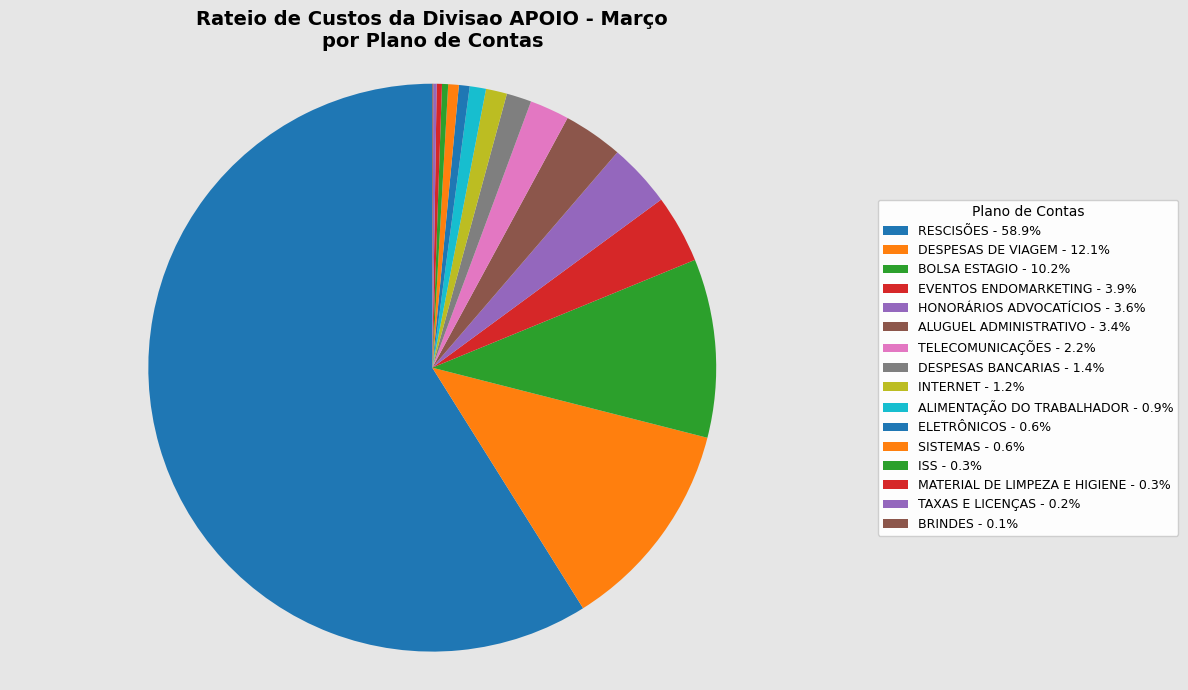

In [6]:
def plotar_pizza_rateio(
    tabela: pd.DataFrame,
    coluna_grupo: str = COLUNA_AGRUPAMENTO,
    coluna_valor: str = "valor_rateado",
    coluna_pct: str | None = "participacao_pct",
    titulo: str = "Rateio de Custos da Divisao APOIO\npor Plano de Contas",
):
    tabela_ord = tabela.sort_values(coluna_valor).reset_index(drop=True)

    valores_abs = tabela_ord[coluna_valor].abs()
    grupos = tabela_ord[coluna_grupo].astype(str)

    if coluna_pct and coluna_pct in tabela_ord.columns:
        pcts = tabela_ord[coluna_pct].astype(float)
    else:
        soma = float(valores_abs.sum())
        pcts = valores_abs / soma * 100 if soma else valores_abs * 0

    legend_labels = [f"{g} - {p:.1f}%" for g, p in zip(grupos, pcts)]

    fig, ax = plt.subplots(figsize=(12, 7), facecolor="#e6e6e6")
    ax.set_facecolor("#e6e6e6")

    wedges, _texts = ax.pie(
        valores_abs,
        labels=None,
        autopct=None,
        startangle=90,
        shadow=False,
    )

    ax.legend(
        wedges,
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        framealpha=0.95,
        title="Plano de Contas",
        title_fontsize=10,
    )
    ax.set_title(titulo, fontsize=14, fontweight="bold")
    ax.axis("equal")
    plt.tight_layout()
    return fig, ax


_titulo_pizza = f"Rateio de Custos da Divisao APOIO - {NOME_MES}\npor Plano de Contas"
fig, ax = plotar_pizza_rateio(resultado, titulo=_titulo_pizza)


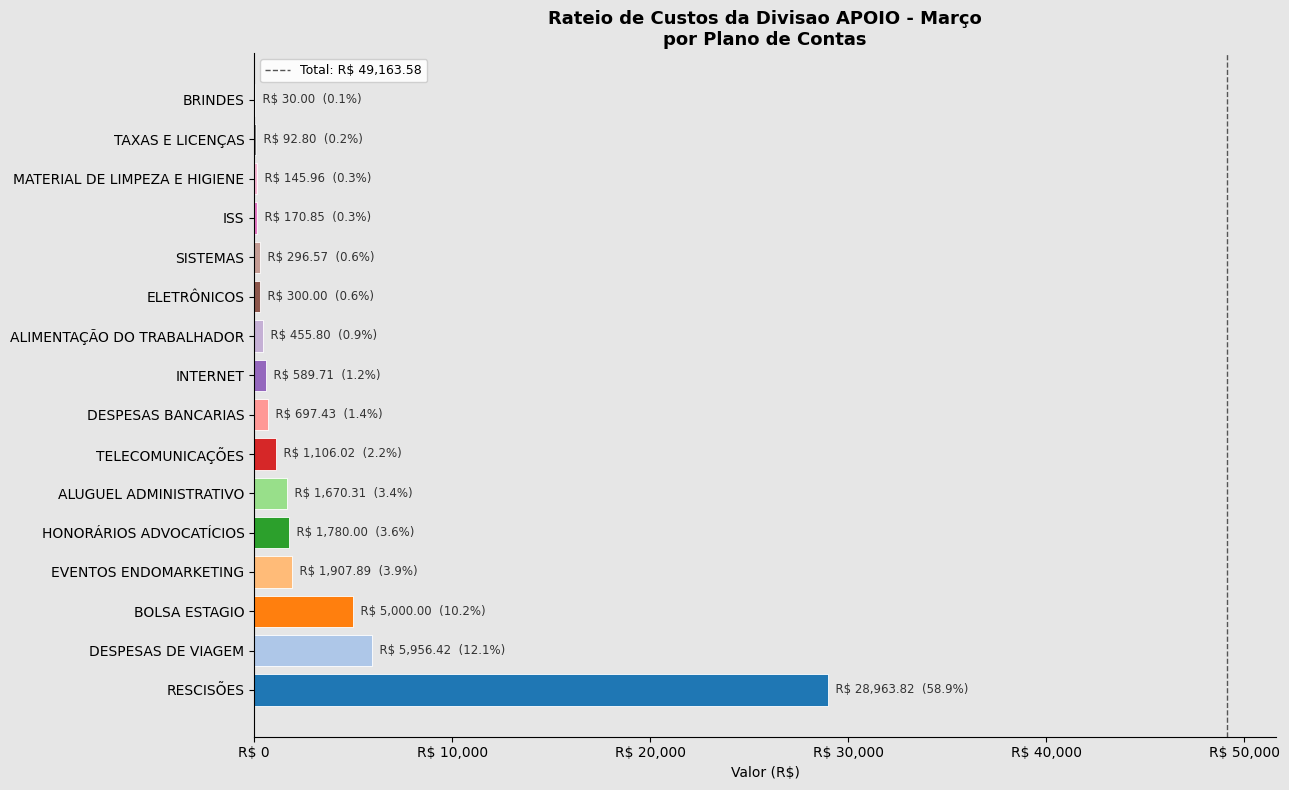

In [7]:
def plotar_barras_rateio(
    tabela: pd.DataFrame,
    coluna_grupo: str = COLUNA_AGRUPAMENTO,
    coluna_valor: str = "valor_rateado",
    coluna_pct: str | None = "participacao_pct",
    titulo: str = "Rateio de Custos da Divisao APOIO\npor Plano de Contas",
):
    # Ordena do maior custo (mais negativo) para o menor — visualmente do topo para baixo
    tabela_ord = tabela.sort_values(coluna_valor, ascending=True).reset_index(drop=True)

    valores_abs = tabela_ord[coluna_valor].abs()
    grupos = tabela_ord[coluna_grupo].astype(str)

    if coluna_pct and coluna_pct in tabela_ord.columns:
        pcts = tabela_ord[coluna_pct].astype(float)
    else:
        soma = float(valores_abs.sum())
        pcts = valores_abs / soma * 100 if soma else valores_abs * 0

    total_abs = float(valores_abs.sum())

    fig, ax = plt.subplots(figsize=(13, max(6, len(grupos) * 0.5)), facecolor="#e6e6e6")
    ax.set_facecolor("#e6e6e6")

    bars = ax.barh(
        grupos,
        valores_abs,
        color=plt.cm.tab20.colors[: len(grupos)],
        edgecolor="white",
        linewidth=0.6,
    )

    # Anota valor (R$) + % em cada barra
    for bar, pct, val in zip(bars, pcts, valores_abs):
        label = f"  R$ {val:,.2f}  ({pct:.1f}%)"
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            ha="left",
            fontsize=8.5,
            color="#333333",
        )

    # Linha do total
    ax.axvline(total_abs, color="#555555", linestyle="--", linewidth=1, label=f"Total: R$ {total_abs:,.2f}")
    ax.legend(fontsize=9, framealpha=0.9)

    ax.set_xlabel("Valor (R$)", fontsize=10)
    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))

    # Remove borda direita e superior para visual mais limpo
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    plt.tight_layout()
    return fig, ax


_titulo_barras = f"Rateio de Custos da Divisao APOIO - {NOME_MES}\npor Plano de Contas"
fig2, ax2 = plotar_barras_rateio(resultado, titulo=_titulo_barras)


In [8]:
# (Opcional) Salvar resultado e graficos com nome do mes
_saida_dir = ROOT / "02-Referencias"
_saida_dir.mkdir(parents=True, exist_ok=True)
saida_excel = _saida_dir / f"rateio_apoio_{NOME_MES}.xlsx"
saida_pizza = _saida_dir / f"rateio_apoio_{NOME_MES}_pizza.png"
saida_barras = _saida_dir / f"rateio_apoio_{NOME_MES}_barras.png"

resultado.to_excel(saida_excel, index=False)
fig.savefig(saida_pizza, dpi=160, bbox_inches="tight")
fig2.savefig(saida_barras, dpi=160, bbox_inches="tight")

print(f"Tabela salva em : {saida_excel.resolve()}")
print(f"Pizza salva em  : {saida_pizza.resolve()}")
print(f"Barras salvo em : {saida_barras.resolve()}")


Tabela salva em : C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\02-Referencias\Rateio_APOIO_Março.xlsx
Pizza salva em  : C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\02-Referencias\rateio_apoio_Março_pizza.png
Barras salvo em : C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\02-Referencias\rateio_apoio_Março_barras.png
